# Cardiovascular Disease Prediction

# Data Collection

## Why It's Important
 Cardiovascular disease is the leading cause of death worldwide, making early detection and prevention critical for public health. Closely observing the factors that contribute to cardiovascular disease can help identify high-risk individuals and inform healthcare strategies.


## Project Objective
This project aims to predict the likelihood of cardiovascular disease based on various health and lifestyle metrics.

## Hypothesis
 Can we predict the presence of cardiovascular disease using routine health and lifestyle data such as age, blood pressure, cholesterol, BMI, smoking, and alcohol intake?

Formal Hypotheses:
- Null Hypothesis (H0): Health and lifestyle features do not significantly predict cardiovascular disease.
- Alternative Hypothesis (H1): Health and lifestyle features significantly predict cardiovascular disease.

Additional Consideration: Which patient features are most strongly associated with cardiovascular disease risk?

## Population
The population consists of adults from Moscow, Russia who underwent medical examinations. The dataset includes a diverse mix of ages, sexes, and lifestyles representing a wide range of demographic, behavioral, and clinical characteristics.

## Variables
The independent variables will include:
- Age (denoted in days)
- Gender (1 = women, 2 = men)
- Height (cm), Weight (kg)
- Blood Pressure (systolic, diastolic)
- Cholesterol, Glucose
- Smoking, Alcohol intake, Physical activity

The dependent variable will be:
- cardio: 1 = diagnosed with cardiovascular disease, 0 = no disease

Cofounding (third) variables could potentially be:
- environmental factors, genetic predisposition, diet, or any other factors that are not captured in the dataset.

  - The confounding variables like environemtal factors are not in the current dataset. In the case for environmental factors, I plan on augemnting and or incorporating it with the current dataset by merging an external dataset like air quality index (AQI) for Moscow, Russia. This will allow me to include a measure of environmental factors (e.g. PM2.5 levels) as a control variable in future modeling steps.

## Plan for data collection

The dataset will be downloaded from Kaggle using the KaggleHub library. It includes roughly 70,000 adult patients. In the future, additional relevant datasets (e.g., environmental data, socioeconomic indicators) could be merged if I need to enhance analysis.


Source:
- Kaggle Cardiovascular Disease dataset
: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset


## Choosing Dataset
Explain why this dataset is interesting to you

This dataset is highly valuable for predictive modeling because it combines clinical measurements (blood pressure, cholesterol, glucose) with lifestyle factors (smoking, alcohol consumption, and physical activity). With 70,000 patient records, it provides a large and diverse sample for statistical analysis and machine learning experiments. Addtionally, the data is clean, tabular and well-structured making it ideal for exploratory data analysis, feature engineering, and classification modeling.


1. What is in the dataset?
- This dataset has 70,000 rows with 12 features.
2. Where is the dataset from?
  - The dataset is from Kaggle
3. When is the dataset from?
- The dataset is from a modern clinical examination from Moscow, Russia

In [1]:
# install kagglehub if not installed
!pip install kagglehub --quiet

import kagglehub as kh
import pandas as pd

# get Cardiovascular Disease dataset path from Kaggle
raw_data_path = kh.dataset_download('sulianova/cardiovascular-disease-dataset')

df = pd.read_csv(raw_data_path + "/cardio_train.csv", sep=";")

print("\nFirst 5 Rows of Dataset:")
print(df.head(5))


Using Colab cache for faster access to the 'cardiovascular-disease-dataset' dataset.

First 5 Rows of Dataset:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


# Data Pre-Processing

## 1. Preliminary information about the Dataset

In [2]:
# Shape of the data
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")

# List of columns
print("\nDataset columns:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# Quick descriptive statistics
df.describe(include='all')


Dataset shape: 70000 rows and 13 columns

Dataset columns:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

Data types:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


As we can see:
- Shape: 70,000 rows x 13 columns
- Variables: id, age, gender, height, weight, ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active, cardio
- Data types are mostly all numeric (either int64 or float64)
- Notice that some blood-pressure values are clearly unrelalistic (e.g. systolic > 16,000 mmHg). We will handle these later in the data cleaning process

## 2. Specific Data Needs

At this stage, we focus mostly on the Kaggle Cardiovascular Disease dataset which contains a comprehensive mix of clinical and lifestyle factors for over 70,000 individuals. This dataset is sufficient for initial preprocessing, exploratory analysis, and model prototyping. In future iterations, I plan to incorporate external datasets that capture environmental and contextual factors, which can serve as potential confounders influencing cardiovascular health outcomes. For now the focus will be on the larger datset that I have currently.

Potential supplementary datasets:

- Moscow Weather Data - NOAA GHCN-Daily
  - This dataset will provide daily weather measurements such as temperature, humidity, and precipitation. Including weather variables will help control for climatic variability, as extreme temperatures and seasonal changes can influence both cardiovascular risk and patient behavior (for example, reduced physical activity or delayed medical visits)
- Air Quality Data (AQI/Pollutants) - World Air Quality Index
  - Air pollution metrics (e.g., PM2.5, PM10, CO, NO₂ levels) are established environmental risk factors for cardiovascular disease. Integrating city-level AQI data for Moscow will allow the inclusion of an environmental exposure variable, offering a more comprehensive view of external health determinants.

## 3. Potential issues in the data




### Duplicate Rows

In [3]:
#check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# If duplicates exist, show them
if duplicates > 0:
    display(df[df.duplicated()])

Number of duplicate rows: 0


Observe that we get 0 duplicates which is a good sign of data integrity

### Missing or Null values

In [4]:
# check for missing values
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)


Missing values per column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


We see that there are no missing values in any column, thus will not require much imputation

### Unique Values per Column

In [5]:
# checking for unique values
unique_counts = df.nunique()
print("\nUnique values per column:")
print(unique_counts)



Unique values per column:
id             70000
age             8076
gender             2
height           109
weight           287
ap_hi            153
ap_lo            157
cholesterol        3
gluc               3
smoke              2
alco               2
active             2
cardio             2
dtype: int64


Key Observations:
- The "id" column has 70,000 unique vaules where each record represents one patient
- Variables like cholesterol, glucose, smoke, alco, active, and cardio have few unique values. This can be beneficial for categorical encoding later on.

### Outliers

In [6]:
# checking for outliers using z-score
from scipy import stats
import numpy as np

numeric_data = ['height', 'weight', 'ap_hi', 'ap_lo']
z_scores = np.abs(stats.zscore(df[numeric_data]))
outliers = (z_scores > 3).any(axis=1)


print("\nChecking for potential outliers per column:")
df[outliers].head()


Checking for potential outliers per column:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
224,309,21800,2,76,55.0,120,80,1,1,0,0,1,0
228,314,17489,2,183,98.0,160,1100,1,2,1,0,1,1
241,334,21932,2,157,60.0,160,1000,2,1,0,0,0,1
260,357,18217,1,150,83.0,140,800,1,1,0,0,1,1
329,458,23407,1,176,63.0,160,1000,2,2,0,0,0,1


We see that there are some extreme outlier found in blood-pressure columns (ap_hi and ap_lo) such as systolic > 1000 mmHg. These are unrealistic and will need to be filtered out.

## 4. Reorganization and Renaming


In [7]:
# rename some column for readability
df.rename(columns={
    'ap_hi': 'systolic_bp',
    'ap_lo': 'diastolic_bp',
    'alco': 'alcohol_intake',
    'active': 'physical_activity'
}, inplace=True)

df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'systolic_bp',
       'diastolic_bp', 'cholesterol', 'gluc', 'smoke', 'alcohol_intake',
       'physical_activity', 'cardio'],
      dtype='object')

These columns were renamed for clarity: e.g. "systolic_bp" instead of "ap_hi" and "physical_activity" instead of "active"

## 5. Data Cleaning Plan

Based on the findings from above, we need to:
- filter the blood pressure values for a realistic range (80-250 / 50-150 mmHg) and reduce data-entry errors
- use realistic height/weight to remove any anamolies - keep 120-220 cm / 30 - 200 kg
- convert age from days to years for easier interpretation
- rename and reorder columns for readability

## 6. Apply Data Cleaning Plan

In [8]:
# remove any duplicates
df.drop_duplicates(inplace=True)

# remove improbable blood-pressure values
df = df[df['systolic_bp'].between(80, 250)]
df = df[df['diastolic_bp'].between(50, 150)]


# remove unrealistic heights and weights
df = df[df['height'].between(120, 220)]
df = df[df['weight'].between(30, 200)]

# convert age from days to years (as integer)
df['age'] = (df['age'] / 365).astype(int)

# reordering columns
cols = ['id', 'age', 'gender', 'height', 'weight', 'systolic_bp',
        'diastolic_bp', 'cholesterol', 'gluc', 'smoke', 'alcohol_intake',
        'physical_activity', 'cardio']

df = df[cols]



## 7. Verify Results after Cleaning

In [9]:
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")
print("\nDataset columns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nChecking for missing values")
print(df.isnull().sum())

df.describe()

Dataset shape: 68665 rows and 13 columns

Dataset columns:
['id', 'age', 'gender', 'height', 'weight', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'gluc', 'smoke', 'alcohol_intake', 'physical_activity', 'cardio']

Data types:
id                     int64
age                    int64
gender                 int64
height                 int64
weight               float64
systolic_bp            int64
diastolic_bp           int64
cholesterol            int64
gluc                   int64
smoke                  int64
alcohol_intake         int64
physical_activity      int64
cardio                 int64
dtype: object

Checking for missing values
id                   0
age                  0
gender               0
height               0
weight               0
systolic_bp          0
diastolic_bp         0
cholesterol          0
gluc                 0
smoke                0
alcohol_intake       0
physical_activity    0
cardio               0
dtype: int64


,id,age,gender,height,weight,systolic_bp,diastolic_bp,cholesterol,gluc,smoke,alcohol_intake,physical_activity,cardio
count,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000
mean,49974.686565,52.829476,1.348809,164.416078,74.121461,126.628078,81.363912,1.364800,1.225938,0.088022,0.053521,0.803379,0.494866
std,28846.844212,6.767963,0.476597,7.914118,14.295434,16.719983,9.522436,0.679024,0.571886,0.283328,0.225071,0.397446,0.499977
min,0.000000,29.000000,1.000000,120.000000,30.000000,80.000000,50.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25002.000000,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50019.000000,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74870.000000,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,64.000000,2.000000,207.000000,200.000000,240.000000,150.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


After cleaning the data we get:
- The number of rows reduced from 70,000 --> 68,665 after removing outliers
- No missing or duplicate values
- normalized ranges for height, weight, and blood pressure to a realistic standard
- The average age of a patient is about 53 years

## 8. Save Cleaned Data



In [10]:
# save cleaned dataset
df.to_csv('cardio_cleaned.csv', index=False)
print("Saved cleaned dataset to 'cardio_cleaned.csv'")

Saved cleaned dataset to 'cardio_cleaned.csv'


## 9. Import Cleaned dataset

In [11]:
# import the cleaned dataset
df_clean_data = pd.read_csv('cardio_cleaned.csv')
print("Loading new dataset with shape:", df_clean_data.shape)

Loading new dataset with shape: (68665, 13)


## 10. Display First and Last 5 Rows

In [12]:
print("\nFirst 5 Rows of Cleaned Dataset:")
print(df_clean_data.head())

print("\nLast 5 Rows of Cleaned Dataset:")
print(df_clean_data.tail())


First 5 Rows of Cleaned Dataset:
   id  age  gender  height  weight  systolic_bp  diastolic_bp  cholesterol  \
0   0   50       2     168    62.0          110            80            1   
1   1   55       1     156    85.0          140            90            3   
2   2   51       1     165    64.0          130            70            3   
3   3   48       2     169    82.0          150           100            1   
4   4   47       1     156    56.0          100            60            1   

   gluc  smoke  alcohol_intake  physical_activity  cardio  
0     1      0               0                  1       0  
1     1      0               0                  1       1  
2     1      0               0                  0       1  
3     1      0               0                  1       1  
4     1      0               0                  0       0  

Last 5 Rows of Cleaned Dataset:
          id  age  gender  height  weight  systolic_bp  diastolic_bp  \
68660  99993   52       2     16

# Data Exploration & Visualization

## Initial Thoughts

**Do we have the right data?**

Yes, I beleive we have the right data for predicting cardiovascualr disease. The cleaned dataset (`cardio_cleaned.csv`) contains 68,665 patient records with key clinical measurements (blood pressure, cholesterol, glucose), demographics (age, gender), and lifestyle factors (smoking, alcohol intake, physical activity). These are well-established risk factors in medical reserach.

However, the data could be enhanced with addtional variables like environmental factors (e.g, air quality). For nowm the current features should provide a solid foundation for building predicitive models.


**Initial Thoughts**

At a first glance, I would expect that age, systolic blood pressure, and smoking will show strong correlations with `cardio`. One key question I want to explore is whether BMI, which we caculated using height and weight, is a good predictor for cardiovascular disease.


**Questions to Explore:**

1. How balanced is the target variable (`cardio`)? Are there are class imbalances that need addressing?
2. Which features show the strongest relationships with cardiovascular disease?
3. What do the numeric variable's (e.g., age, BMI, blood pressure) distributions look like? Do we see any skew or outliers?
4. Are there strong correlations between predictors that might cause multicollinearity?
5. Do lifestyle factors (smoking, alcohol, physical activity) show expected patterns?
6. Does BMI, calculated from height and weight, serve as a good predictor?
6. Do relationships vary across subgroups (e.g., gender distribution)?

## Characteristics of the data



In [13]:
# Each record in the dataset represents one patient

# Dataset Shape
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())


# Counts for target (cardio) and gender
print("\nCardio Distribution:\n", df['cardio'].value_counts(normalize=False))
print("\nCardio proportion:\n", df['cardio'].value_counts(normalize=True))
print("\nGender Distribution:\n", df['gender'].value_counts())


Shape: (68665, 13)

Columns: ['id', 'age', 'gender', 'height', 'weight', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'gluc', 'smoke', 'alcohol_intake', 'physical_activity', 'cardio']

Cardio Distribution:
 cardio
0    34685
1    33980
Name: count, dtype: int64

Cardio proportion:
 cardio
0    0.505134
1    0.494866
Name: proportion, dtype: float64

Gender Distribution:
 gender
1    44714
2    23951
Name: count, dtype: int64


**Shape of the Data:**
- 68,665 row (patients) and 13 columns (variables)

**What each row represents:**
- Each row represents one patient from Moscow, Russia who underwent a medical examination. The data includes clinical measurements, demographic information, and lifestyle factors at the time of examination.

**Variables:**
- `id`: Patient identifier
- `age`: Age in years (convereted from days during preprocessing)
- `gender`: 1 = Female, 2 = Male
- `height`: Height in cm
- `weight`: Weight in kg
- `systolic_bp`: Systolic blood pressure in mmHg (millimeters of mercury)
- `diastolic_bp`: Diastolic blood pressure in mmHg
- `cholesterol`: 1 = normal, 2 = above normal, 3 = well above normal
- `gluc`: Glucose levels (same as cholesterol)
- `smoke`: 0 = No, 1 = Yes
- `alcohol_intake`: 0 = No, 1 = Yes
- `physical_activity`: 0 = No, 1 = Yes
- `cardio`: Our target variable, 0 = no cardiovascular disease, 1 = has cardiovascular disease

**Duplicates:**

During preprocessing, we verified that no duplicates were found in the dataset by using `.duplicated()` method which returned 0 duplicate rows. Since no duplicate rows exist, no further handling is needed.


## Additional Transformations / derived variables

In [14]:
# 1. Creating BMI from height
df['height_meters'] = df['height'] / 100.0
df['bmi'] = df['weight'] / (df['height_meters'] ** 2)

# 2. Adding a new gender label column for better readability
df['gender_label'] = df['gender'].map({1: 'Female', 2: 'Male'})

# 3. Creating blood pressure categories (based on medical guidelines)
def categorize_blood_pressure(row):
  # These categorization calcuations came from the World Health Organization
  # and NHLBI (National Heart Lung and Blood Institue)
  if row['systolic_bp'] < 120 and row['diastolic_bp'] < 80:
    return 'Normal'
  elif row['systolic_bp'] < 130 and row['diastolic_bp'] < 80:
    return 'Elevated'
  elif row['systolic_bp'] < 140 or row['diastolic_bp'] < 90:
    return 'Stage 1 Hypertension'
  else:
    return 'Stage 2 Hypertension'

df['bp_category'] = df.apply(categorize_blood_pressure, axis=1)


# 4. Categorize BMI
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(categorize_bmi)

# Old + New features
df[['bmi', 'bmi_category', 'gender', 'gender_label', 'systolic_bp', 'diastolic_bp', 'bp_category']].head(10)

,bmi,bmi_category,gender,gender_label,systolic_bp,diastolic_bp,bp_category
0,21.967120,Normal,2,Male,110,80,Stage 1 Hypertension
1,34.927679,Obese,1,Female,140,90,Stage 2 Hypertension
2,23.507805,Normal,1,Female,130,70,Stage 1 Hypertension
3,28.710479,Overweight,2,Male,150,100,Stage 2 Hypertension
4,23.011177,Normal,1,Female,100,60,Normal
5,29.384676,Overweight,1,Female,120,80,Stage 1 Hypertension
6,37.729725,Obese,1,Female,130,80,Stage 1 Hypertension
7,29.983588,Overweight,2,Male,130,90,Stage 1 Hypertension
8,28.440955,Overweight,1,Female,110,70,Normal
9,25.282570,Overweight,1,Female,110,60,Normal


**Transformations Applied:**

1. **BMI (Body Mass Index) Caculation**
   - Created the dervied feature `bmi` using the following formula `bmi = weight / (height_in_meters)`
   -  BMI is a well-established indicator of cardiovascular risk and combines height/weight into a single meanigful metric
   - This helps reduces multicollinearity between heigh and weight variables

2. **Gender Label Mapping**
   - Here, we mapped numeric codes to readbale labels `gender_label` where 1 denotes female and 2 as male
   - This helps improve interpretability of future results and visualizations
   - Note that we kept the original `gender` column as this will be retained for modeling

3. **Blood Pressure Categories**
   - Created a new `bp_category` column that categorizes the patients blood pressure based using the `systolic_bp` and `diastolic_bp`
   - The calculations for categorization were dervied from these references:
      - WHO: https://www.who.int/news-room/fact-sheets/detail/hypertension#:~:text=Lifestyle%20changes%20like%20eating%20a,days%20is%20%E2%89%A590%20mmHg.
      - NHLBI: https://www.nhlbi.nih.gov/health/high-blood-pressure#:~:text=Table_title:%20Blood%20pressure%20levels%20Table_content:%20header:%20%7C,OR%2090%20or%20higher%20diastolic%20pressure%20%7C
   - These categorical groupings can capture non-linear relationships and align with clinical decision-making

4. **BMI Categories**
   - Created `bmi_category`: Underweight (<18.5), Normal (18.5-25), Overweight(25-30), and Obese (>=30)
   - The BMI values came from a research paper that focused on obesity in Moscow, Russia
     - Obesity Research Paper: https://www.mdpi.com/1660-4601/17/6/1937#:~:text=BMI%20(kg/m2),based%20on%20BMI%20%5B22%5D.

These engineered features provide both continuous and categorical options for modeling, allowing us to capture linear and non-linear relationships with cardiovascular disease.

## Exploring Variables

### Age

count    68665.000000
mean        52.829476
std          6.767963
min         29.000000
25%         48.000000
50%         53.000000
75%         58.000000
max         64.000000
Name: age, dtype: float64


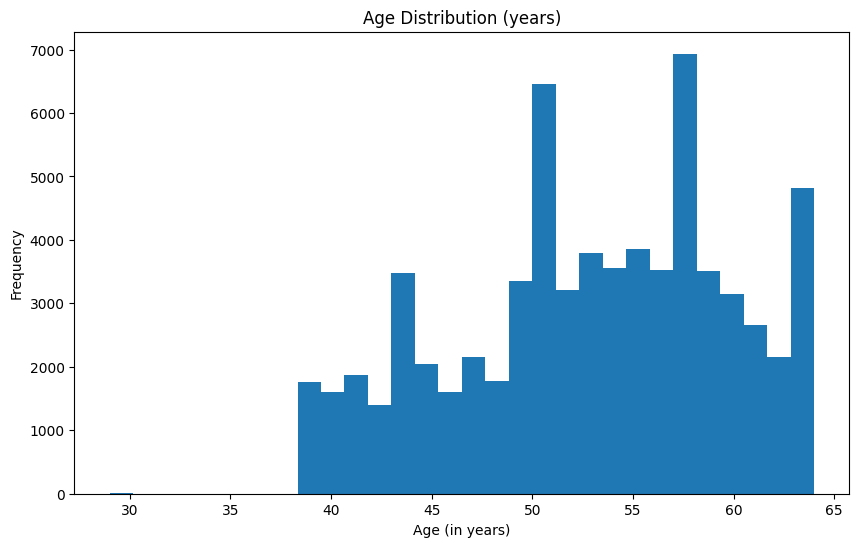

In [15]:
import matplotlib.pyplot as plt

print(df['age'].describe())


plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=30)
plt.xlabel('Age (in years)')
plt.ylabel('Frequency')
plt.title('Age Distribution (years)')
plt.show()

**Age Analysis**
- **Data Type:** Integer (int64)
- **Units:** Years
- **What it represents:** Patient's age at time of medical examination
- **Transformation:** Converted from days to years (done in preprocessing above)
- **Missing data:** None
- **Outliers:** No extreme outliers detected - range is resonable for the adult population study
- **Descriptive Statistics:**
  - Mean: 52.8 years
  - Standard Deviation: 6.8 years
  - Range: 29-64
  - IQR: 49-58 (roughly 50% of the data lies between this range)
- **Distribution:** This is roughly a normal distribution with a slight concentration around 50-55 years
- The dataset focuses on middle-aged to older adults from Moscow, Russia. This age range is appropriate for cardiovascualr disease research as risk increases with age.

### BMI, Height, Weight

count    68665.000000
mean        27.459055
std          5.256908
min         10.726644
25%         23.875115
50%         26.346494
75%         30.119376
max        108.169847
Name: bmi, dtype: float64


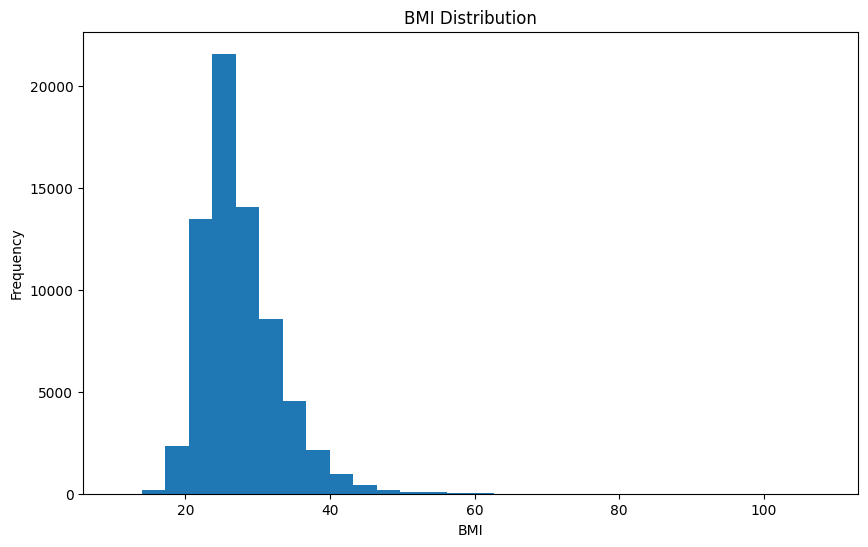

In [16]:
print(df['bmi'].describe())

plt.figure(figsize=(10, 6))
plt.hist(df['bmi'], bins=30)
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('BMI Distribution')
plt.show()



**BMI Analysis**
- **Data Type:** Float (float64)
- **Units:** kg/m^2
- **What it represents:** Patient's BMI that is calculated from their height and weight
- **Transformation:** This is a derived feature created during exploration (bmi = weight / height_in_meters ^ 2)
- **Missing data:** None as this was derived from complete data
- **Outliers:** Some high outlier (108), but for the most part the data is reasonable
- **Descriptive Statistics:**
  - Mean: 27.5 kg/m^2
  - Standard Deviation: 5.3 kg/m^2
  - Range: 10.7-108.2 kg/m^2
- **Distribution:** Right-skewed with most values between 23-30
- The mean BMI is 27.5 which indicates that the average patient from the study is in the overweight category (25-30). The right skew shows some patients with very high BMI (obsese). This is a medically relevant as higher BMI is generally associated with risk of cardiovascular disease.

count    68665.000000
mean       164.416078
std          7.914118
min        120.000000
25%        159.000000
50%        165.000000
75%        170.000000
max        207.000000
Name: height, dtype: float64


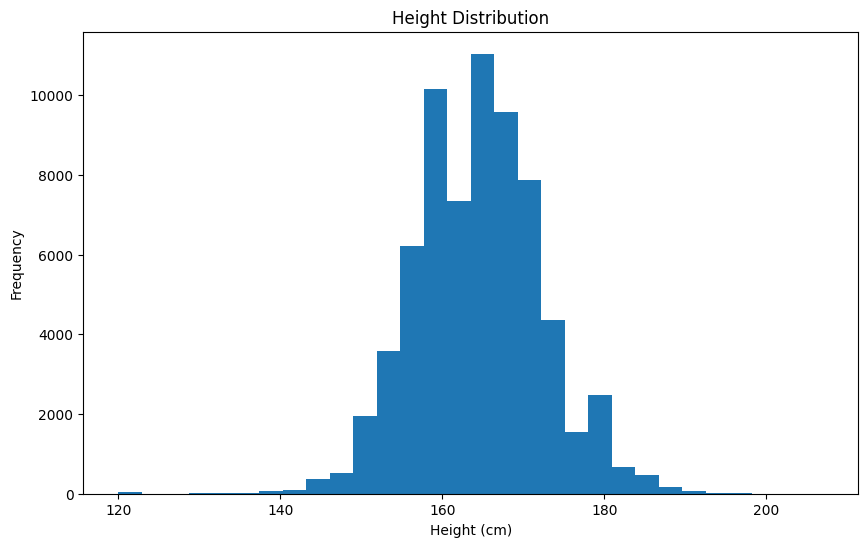

In [17]:
print(df['height'].describe())

plt.figure(figsize=(10, 6))
plt.hist(df['height'], bins=30)
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.title('Height Distribution')
plt.show()

**Height Analysis**
- **Data Type:** Integer (int64)
- **Units:** centimeters (cm)
- **What it represents:** Patient's height measurement
- **Transformation:** Outliers removed during preprocessing (kept 120-220 cm range)
- **Missing data:** None
- **Outliers:** SNo extreme outlier after cleaning the data
- **Descriptive Statistics:**
  - Mean: 164.4 cm (~5'5")
  - Median: 165 cm
  - Standard Deviation: 7.9 cm
  - Range: 120-207 cm
- **Distribution:** Normal distribution, looks almost symmetric around the mean
- Height distribution is as expected for an adult population with good data quality.

count    68665.000000
mean        74.121461
std         14.295434
min         30.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        200.000000
Name: weight, dtype: float64


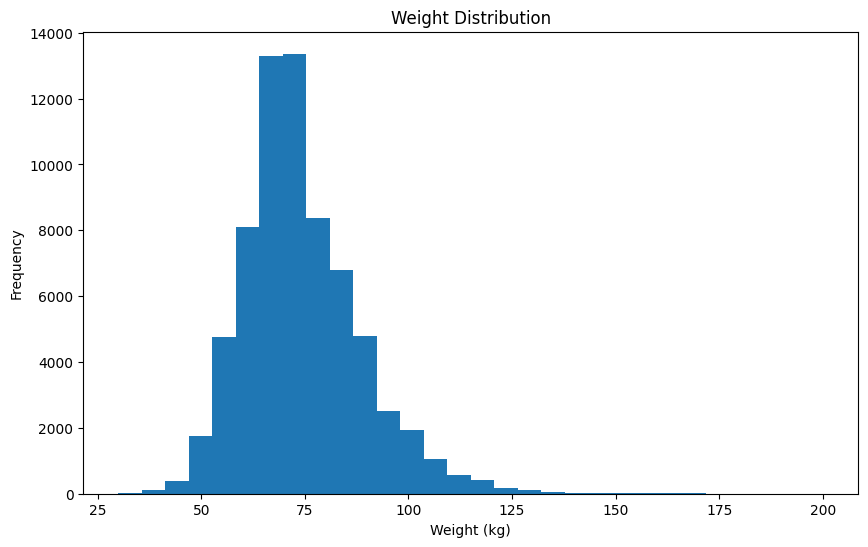

In [18]:
print(df['weight'].describe())

plt.figure(figsize=(10, 6))
plt.hist(df['weight'], bins=30)
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.title('Weight Distribution')
plt.show()

**Weight Analysis**
- **Data Type:** Float (float64)
- **Units:** Kilograms (kg)
- **What it represents:** Patient's body weight measurement
- **Transformation:** Outliers removed during preprocessing (kept 30-200 kg)
- **Missing data:** None
- **Outliers:** No extreme outliers after preprocessing
- **Descriptive Statistics:**
  - Mean: 74.1 kg (~163 lbs)
  - Median: 72 kg
  - Standard Deviation: 14.3 kg
  - Range: 30-200 kg
- **Distribution:** Fairly normal with a slight right skew
- The weight distribution is reasonable for an adult population. The slight right skew aligns with BMI observations showing some patients in higher weight categories

### Blood Pressure (systolic/diastolic)

        systolic_bp  diastolic_bp
count  68665.000000  68665.000000
mean     126.628078     81.363912
std       16.719983      9.522436
min       80.000000     50.000000
25%      120.000000     80.000000
50%      120.000000     80.000000
75%      140.000000     90.000000
max      240.000000    150.000000


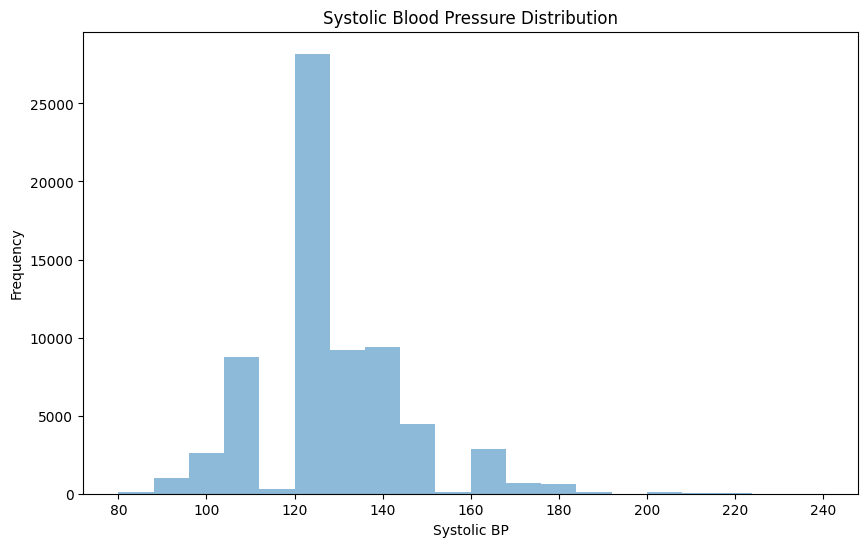

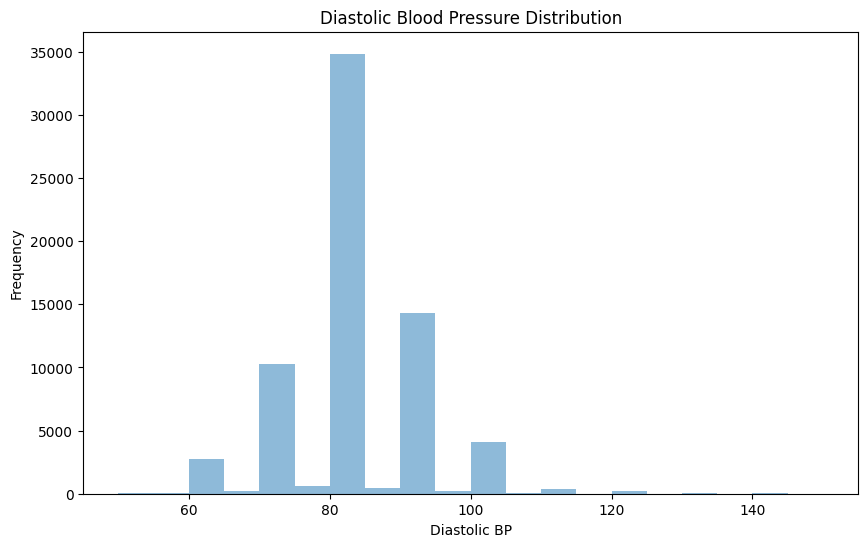

In [19]:
print(df[['systolic_bp', 'diastolic_bp']].describe())

plt.figure(figsize=(10, 6))
plt.hist(df['systolic_bp'], bins=20, alpha=0.5, label='Systolic BP')
plt.title('Systolic Blood Pressure Distribution')
plt.xlabel('Systolic BP')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(10, 6))
plt.hist(df['diastolic_bp'], bins=20, alpha=0.5, label='Diastolic BP')
plt.title('Diastolic Blood Pressure Distribution')
plt.xlabel('Diastolic BP')
plt.ylabel('Frequency')
plt.show()

**Blood Pressure Analysis**
- **Data Type:** Integer (int64) for both systolic and diastolic
- **Units:** mmHg (millimeters of mercury)
- **What it represents:** Systolic (heart contracting) and diastolic (heart resting) blood pressure
- **Transformations:** Outliers removed during preprocessing
- **Missing data:** None
- **Outliers:** No extreme outlier after cleaning the data
- **Descriptive Statistics:**
  - Systolic
    - Mean: 127 mmHg
    - Median: 120 mmHg
    - Range: 80-240 mmHg
  - Diastolic:
    - Mean: 81 mmHg
    - Median: 80 mmHg
    - Range: 50-150 mmHg
- **Distribution:**
   - Systolic: peaks around 120-140 mmHg (normal to stage 1 hypertension range)
  - Diastolic: peaks around 80-90 mmHg (normal to elevated)
- Both measurements show concentration in clinically meaningful ranges. Observe that many patients have elevated or hypertensive readings, which make sense as we are looking at a cardiovascular disease study population.

### Categorical variables


Count for: cholesterol
cholesterol
1    51490
2     9301
3     7874
Name: count, dtype: int64


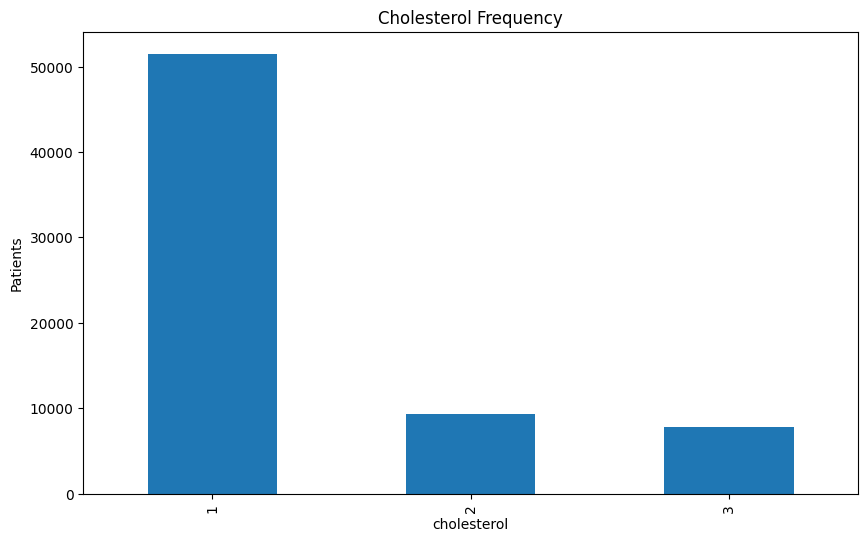


Count for: gluc
gluc
1    58375
3     5224
2     5066
Name: count, dtype: int64


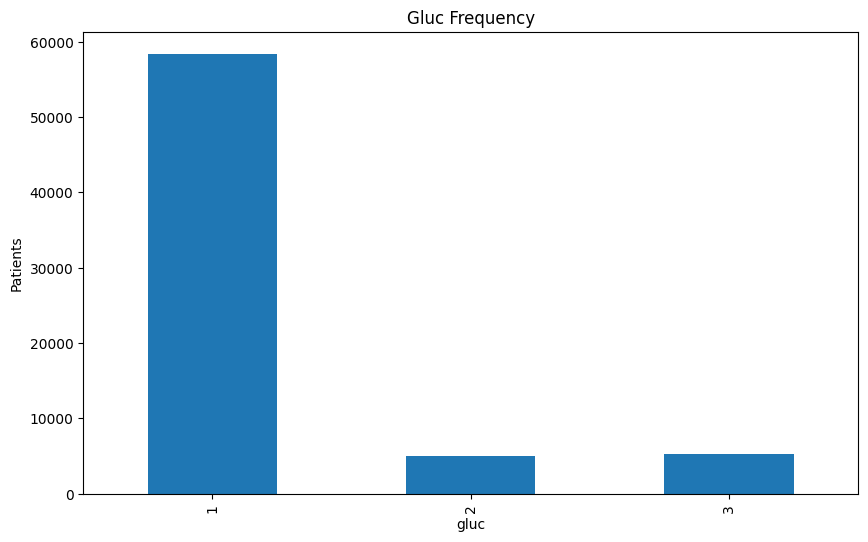


Count for: smoke
smoke
0    62621
1     6044
Name: count, dtype: int64


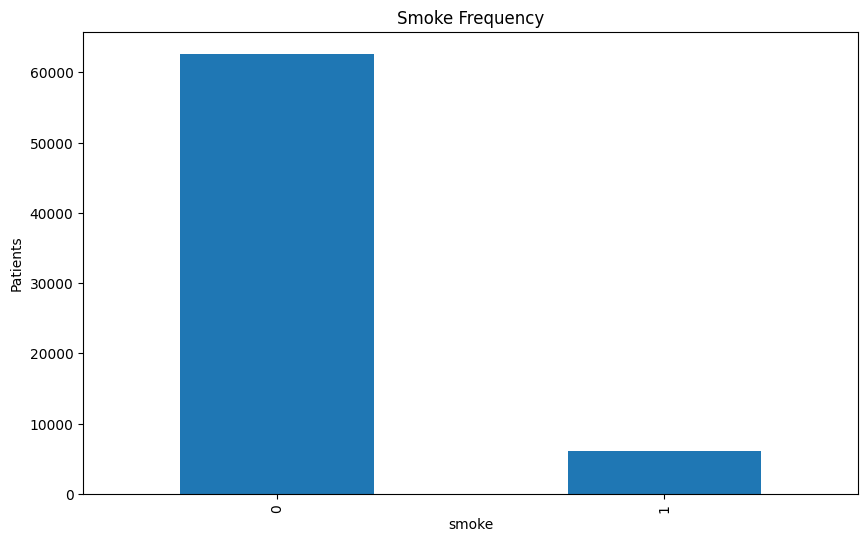


Count for: alcohol_intake
alcohol_intake
0    64990
1     3675
Name: count, dtype: int64


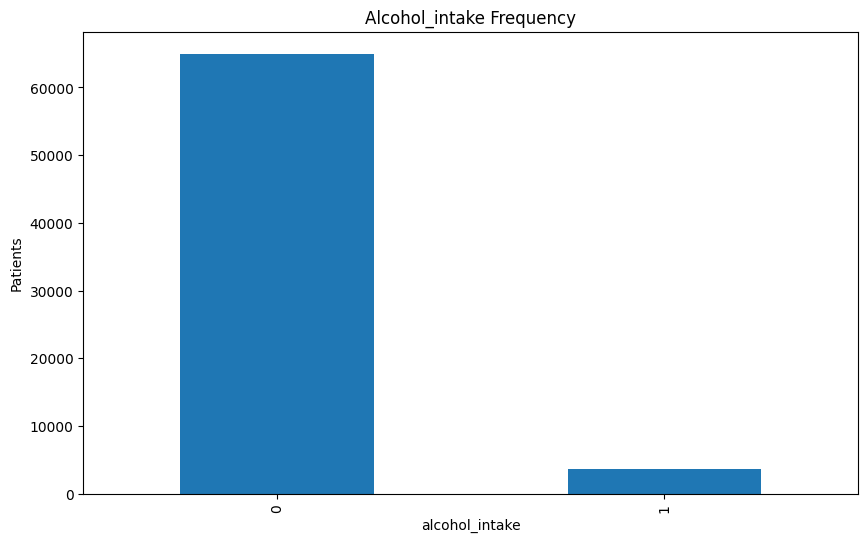


Count for: physical_activity
physical_activity
1    55164
0    13501
Name: count, dtype: int64


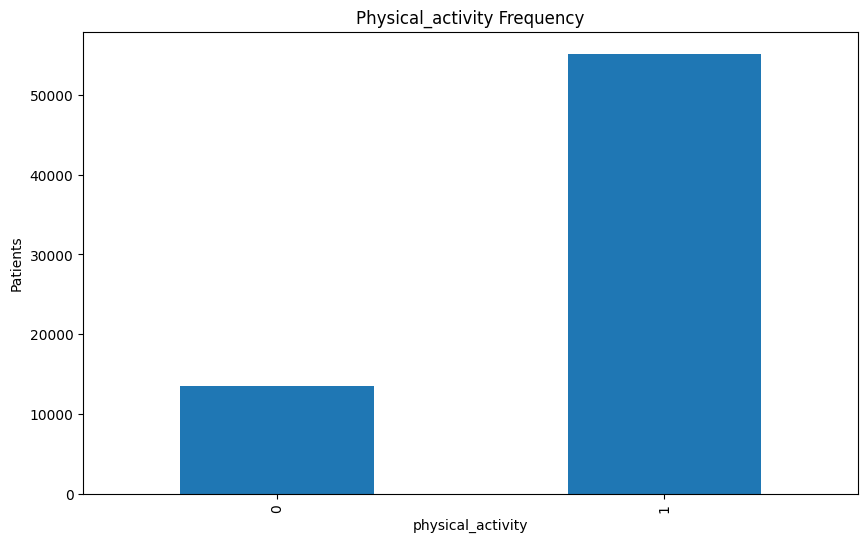

In [20]:
categorical = ['cholesterol', 'gluc', 'smoke', 'alcohol_intake', 'physical_activity']

for cat in categorical:
    print("\nCount for:", cat)
    print(df[cat].value_counts(normalize=False))

    plt.figure(figsize=(10, 6))
    df[cat].value_counts().sort_index().plot(kind='bar')
    plt.title(f'{cat.capitalize()} Frequency')
    plt.xlabel(cat)
    plt.ylabel("Patients")
    plt.show()

**Categorical Variables Analysis**
- **Data Type:** Integer (int64) - encoded as numeric categories or binary
- **Units:**
  - **Cholesterol:** categorical scale (1, 2, 3) representing ordinal levels based on clinical thresholds
  - **Glucose:** ategorical scale (1, 2, 3) representing ordinal levels based on clinical thresholds
  - **Smoke:** binary (0, 1) - unitless indicatior
  - **Alcohol:** binary (0, 1) - unitless indicatior
  - **Physical Activity:** binary (0, 1) - unitless indicatior
- **What they represent:
  - **Cholesterol/Glucose:** 1=normal, 2=above normal, 3=well above normal
  - **Smoke/Alcohol/Physical Activity:** 0=no, 1=yes
- **Transformations:** Already encoded
- **Missing data:** None
- **Outliers:** No extreme outlier after cleaning the data
- **Frequencies:**
  - Cholesterol
    - 75% normal (1)
    - 14% above normal (2)
    - 11% well above normal (3)
  - Glucose
    - 85% normal (1)
    - ~7.5% each for levels 2 and 3
  - Smoke
    - 91% non-smokers
    - 9% smokers
  - Alcohol
    - 95% no alcohol consumption
    - 5% alcohol consumption
  - Physical Activity
    - 80% active
    - 20% inactive
- Observing the bar charts, we can say that most patients have normal cholesterol and glucose. Smoking and alcohol consumption rates are relatively low, while most patients report being physically active. These distributions may affect the predicitive power of lifestyle variables.

### Cardio

cardio
0    34685
1    33980
Name: count, dtype: int64


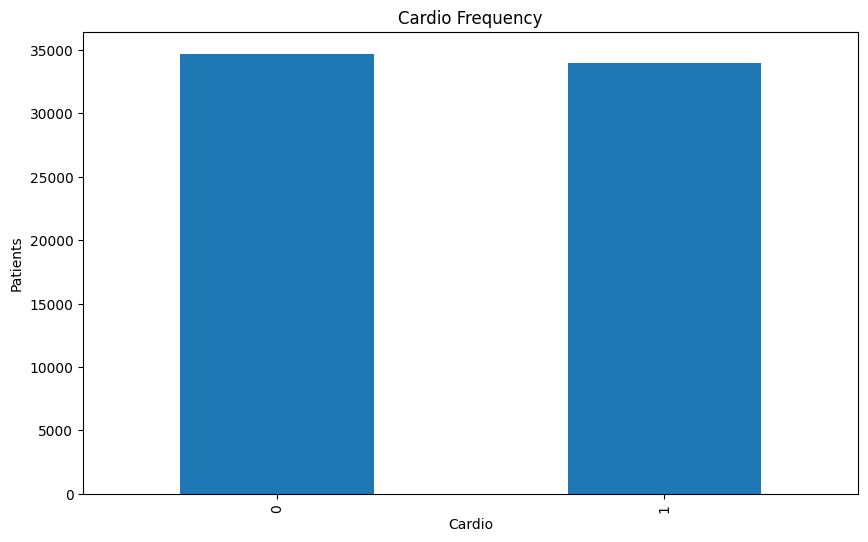

In [21]:
print(df['cardio'].value_counts(normalize=False))

plt.figure(figsize=(10, 6))
df['cardio'].value_counts().plot(kind='bar')
plt.title('Cardio Frequency')
plt.xlabel('Cardio')
plt.ylabel("Patients")
plt.show()

**Target Variable (`cardio`) Analysis**
- **Data Type:** Integer (int64)
- **Units:** binary (0 or 1)
- **What it represents:** Presence of cardiovascular disease (0=no, 1=yes)
- **Transformation:** None required
- **Missing data:** None
- **Outliers:** None, it is only 0s and 1s
- **Descriptive Statistics:**
  - Class 0 (no disease): 34,685 patients (50.5%)
  - Class 1 (has disease): 33,980 patients (49.5%)
- The target variable is well-balanced with nearly a 50-50 split. This will be ideal for modeling as it eliminates the need for class balancing techniques (such as SMOTE, undersampling, etc.) and ensures fair representation of both outcomes.

## Eploring Relationships between variables

### Correlation matrix

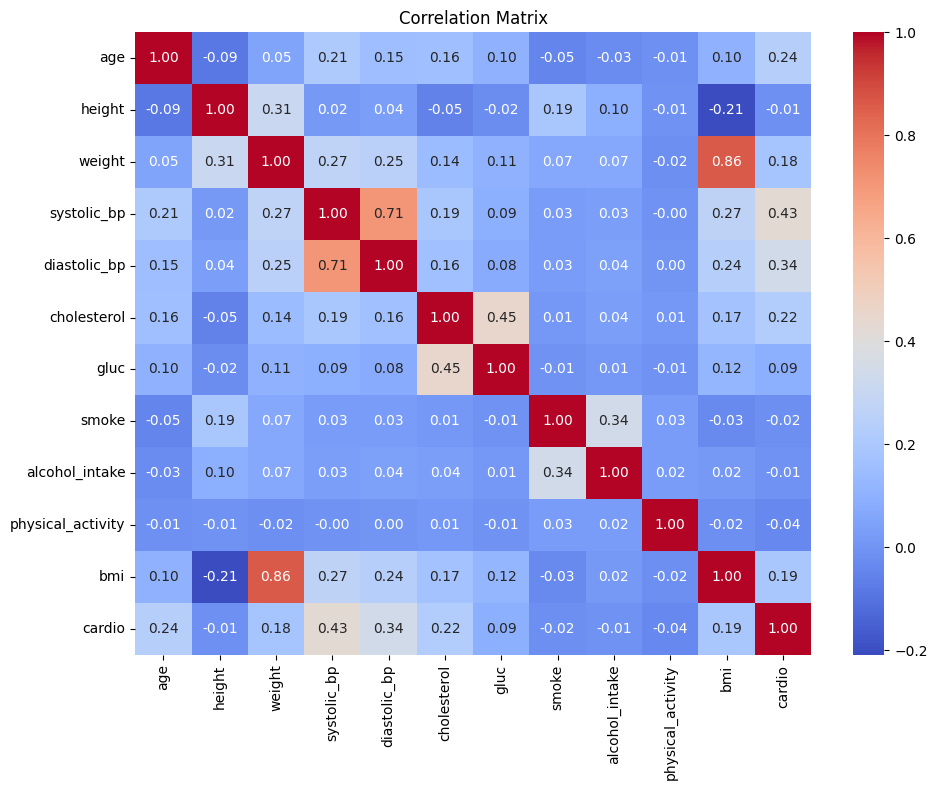


Correlation with cardio
cardio               1.000000
systolic_bp          0.425542
diastolic_bp         0.339333
age                  0.239230
cholesterol          0.221443
bmi                  0.189354
weight               0.179886
gluc                 0.090085
alcohol_intake      -0.008106
height              -0.011864
smoke               -0.016138
physical_activity   -0.037657
Name: cardio, dtype: float64


In [22]:
import seaborn as sns

numeric_cols = ['age', 'height', 'weight', 'systolic_bp', 'diastolic_bp',
                'cholesterol', 'gluc', 'smoke', 'alcohol_intake', 'physical_activity',
                'bmi', 'cardio']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nCorrelation with cardio")
print(corr_matrix['cardio'].sort_values(ascending=False))

Observe that the strongest correlation with `cardio` are:
- `systolic_bp` - 0.43
- `diastolic_bp` - 0.34
- `age` - 0.24
- `cholesterol` - 0.22
- `bmi` - 0.19
- `weight` - 0.18

Interestingly, lifestyle factors show very weak or negative correlations. This could suggest that the lifestyle factors in the dataset are less predictive than clinical measurements, or may need further investigation for data quality.

### Comparing continuous variables by cardio status

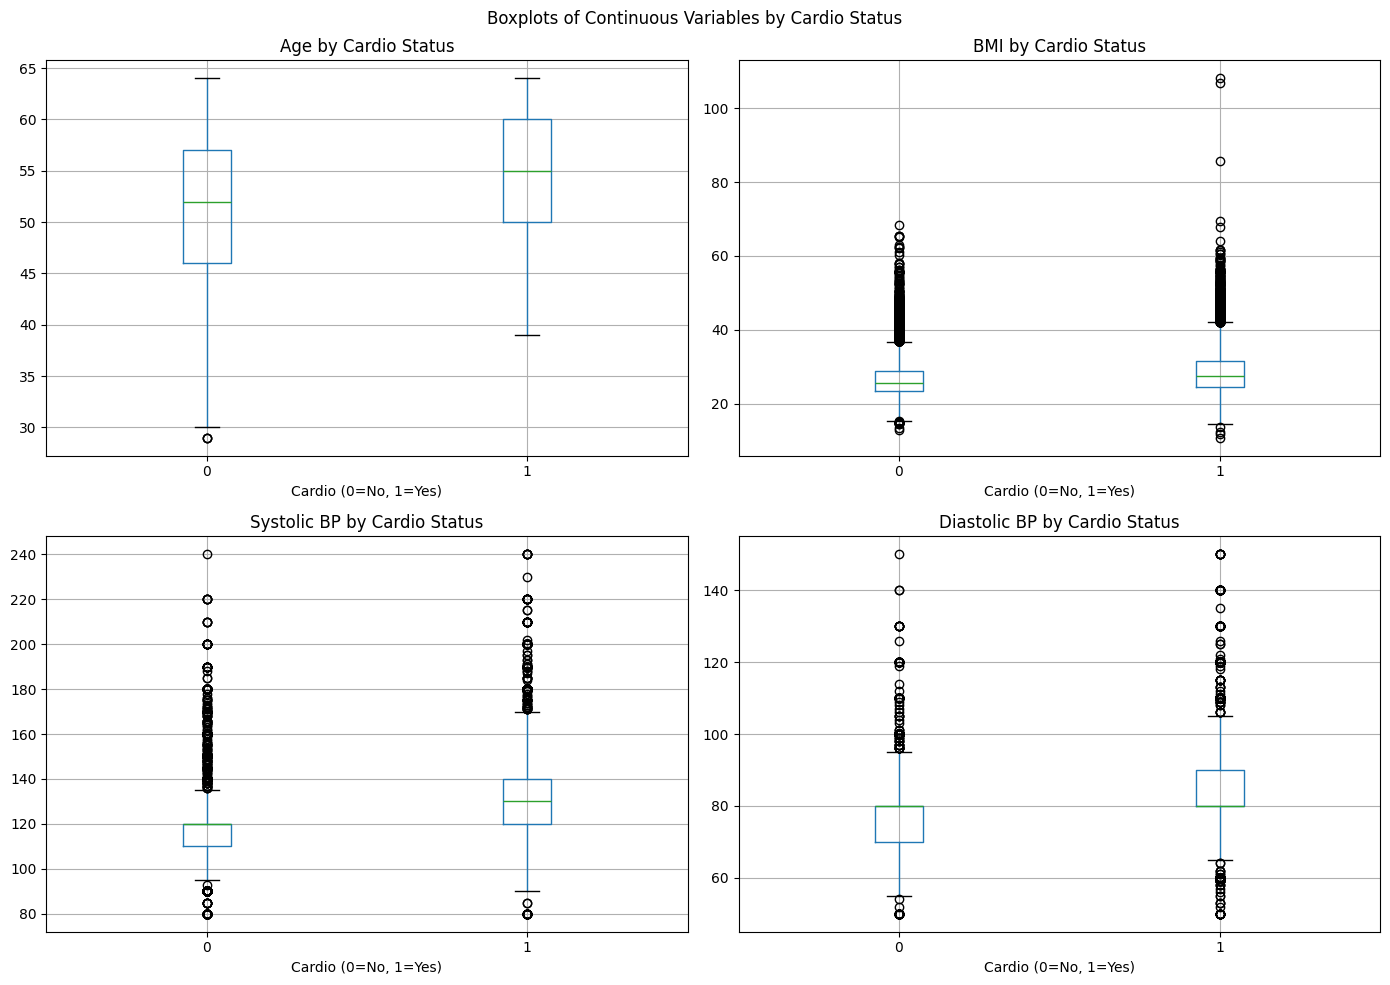

Mean values by cardio status:
               age        bmi  systolic_bp  diastolic_bp
cardio                                                 
0       51.226928  26.473814   119.585758     78.165662
1       54.465274  28.464737   133.816510     84.628517


In [23]:
# We will now compare continuous variables with cardio
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Age
df.boxplot(column='age', by='cardio', ax=axes[0,0])
axes[0,0].set_title('Age by Cardio Status')
axes[0,0].set_xlabel('Cardio (0=No, 1=Yes)')

# BMI
df.boxplot(column='bmi', by='cardio', ax=axes[0,1])
axes[0,1].set_title('BMI by Cardio Status')
axes[0,1].set_xlabel('Cardio (0=No, 1=Yes)')

# Systolic BP
df.boxplot(column='systolic_bp', by='cardio', ax=axes[1,0])
axes[1,0].set_title('Systolic BP by Cardio Status')
axes[1,0].set_xlabel('Cardio (0=No, 1=Yes)')

# Diastolic BP
df.boxplot(column='diastolic_bp', by='cardio', ax=axes[1,1])
axes[1,1].set_title('Diastolic BP by Cardio Status')
axes[1,1].set_xlabel('Cardio (0=No, 1=Yes)')

plt.suptitle('Boxplots of Continuous Variables by Cardio Status')
plt.tight_layout()
plt.show()

categorical_features = ['age', 'bmi', 'systolic_bp', 'diastolic_bp']

print("Mean values by cardio status:\n", df.groupby('cardio')[categorical_features].mean())

**Key Observations:**

Patients with cardiovascualr disease show higher values across all clinical measures:
 - Age: 54 years vs 51 year (3 year difference)
    - modest but consistent - older patients have higher risk
 - BMI: 28 vs 26.5 (1.5 point difference)
    - both groups average in overweight range, cardio patients slightly higher
 - Systolic BP: 133 mmHg vs 120 mmHg (13 mmHg difference)
    - largest separation where cardio group is in Stage 1 hypertension range
    - Non-cardio group is at upper normal/pre-hypertension
    - confirms our belief that blood pressure is a strong predictor for cardiovascular disease
 - Diastolic BP: 85 mmHg vs 78 mmHg (7 mmHg difference)
    - this also shows a clear separation
    -  cardio group exceeds normal threshold (>80)

  

### Categorical variables vs `cardio`

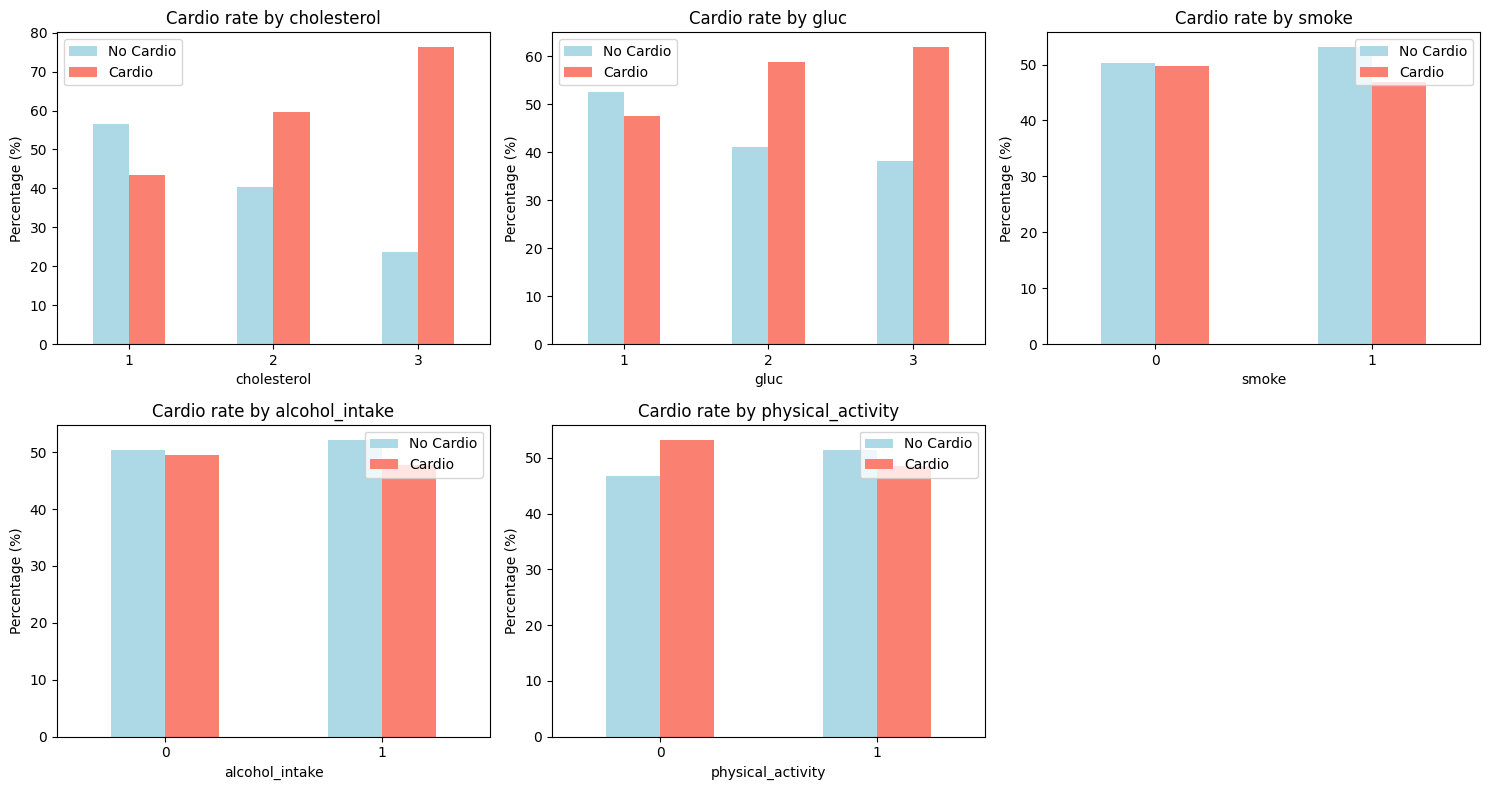


Cholesterol vs Cardio
cardio          0     1
cholesterol            
1            56.4  43.6
2            40.4  59.6
3            23.7  76.3

Gluc vs Cardio
cardio     0     1
gluc              
1       52.4  47.6
2       41.1  58.9
3       38.1  61.9

Smoke vs Cardio
cardio     0     1
smoke             
0       50.3  49.7
1       53.1  46.9

Alcohol_intake vs Cardio
cardio             0     1
alcohol_intake            
0               50.4  49.6
1               52.2  47.8

Physical_activity vs Cardio
cardio                0     1
physical_activity            
0                  46.7  53.3
1                  51.4  48.6


In [24]:
categorical_vars = ['cholesterol', 'gluc', 'smoke', 'alcohol_intake', 'physical_activity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# plotting categorical vs cardio
for i, var in enumerate[str](categorical_vars):
    ct = pd.crosstab(df[var], df['cardio'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['lightblue', 'salmon'])
    axes[i].set_title(f'Cardio rate by {var}')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(['No Cardio', 'Cardio'])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

# remove extra subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# print percentages
for var in categorical_vars:
    print(f"\n{var.capitalize()} vs Cardio")
    ct = pd.crosstab(df[var], df['cardio'], normalize='index') * 100
    print(ct.round(1))

**Categorical Variable Interpretation:**

1. **Strong Realtionships (Cholesterol & Glucose):**
   - Cholesterol:
      - Level 1 (normal): ~43% cardio rate
      - Level 2 (above normal): ~60% cardio rate
      - Level 3 (well above normal): ~71% cardio rate
      - As cholesterol increases, cardiovascular disease rate nearly doubles from normal to high levels
   - Glucose:
      - Level 1 (normal): lower cardio rates
      - Levels 2-3 (elevated): substantially higher cardio rates
      - This strongly aligns with well known medical knowledge where diabetes/prediabetes to heart disease

2. **Moderate Realtionships (Physical Activity):**
   - Active individuals: ~48% cardio rate
   - Inactive individuals: ~53% cardio rate
   - This shows protective effect (with a 5% difference between the two) and thus tells us that the effect is present but modest compared to BP and cholesterol impact

3. **Weak/Unexpected Realtionships (Smokign & Alcohol):**
   - **Smoking:** Nearly identical cardio rates for smokers (~50%) and non-smokers (~49%)
   - **Alcohol:** Minimal difference between consumers and non-consumers
   - These findings are counterintuitive given that there are established mdecial evidence linking smoking to cardiovascualr disease

Overall cholesterol and glucose levels show strong relationships with cardio where higher levels correlates with higher disease rates. Physical activity shows protective effect. Surprisingly, smoking and alcohol show weak associations.

## Do I Trust This Data?

Yes, this data is reasonable for modeling and trying to predict whether someone will get cardiovascular disease or not.

**Strengths:**
  - Large sample size (68,665 records)
  - No missing values
  - Balanced target variabel (50/50 split)
  - Realistic ranges after preprocessing
  - Expected relationships (e.g., BP, cholesterol correlates with cardio)

**Limitations:**
  - Data has missing confounder variables such as environmental factors (e.g., AQI) that were planned but couldn't be added due to lack of timestamps in the dataset
  - Smoking shows unexpected weak association
  - Data is only from Moscow and may not generalize to other populations

For now, the dataset is sufficient. The clinical variables (BP, cholesterol, glucose) are the primary predictors based on medical research. Environmental data would be valuable but is secondary. For future work, if timestamps become available, external datasets like Moscow AQI would be incorporated.

## Wrap Up
Through data exploration, we identified blood pressure (0.43 and 0.34), cholesterol (0.22), age (0.24), BMI (0.19) as the strongest predictors of cardiovascular disease, with clinical measurements showing clear dose-response relationship (e.g., cholesterol gradient goign from 42% normal -> 71% high levels). Unexpectedly, lifestyle factors showed weak associataion despite medical evidence. Our original hypothesis that health and lifestyle feature would significantly predict cardiovascular disease was partially confirmed - clinical features (BMI, cholesterol, glucose, age, BP).

# Analysis, Hypothesis Testing, and ML

## ML Task

Taking a look at the hypothesis we defined above, we are trying to find out if health and lifestyle data such as age, blood pressure, cholesterol, BMI, smoking, and alcohol intake can predict the likelihood of a patient having cardiovascular disease. Given that our dataset is labeled (supervised learning) as each patient has our target variable (`cardio`) defined that states whether a patient has cardiovascualr disease (0 = no, 1 = yes) given their medical information, this is a binary classification task. At a high level, we will use this data to train an ML model to learn from in order to identify key patterns and accurately predict the presence of the disease within new patients. To validate the performance of our model, we will use various evaluation metrics like accuracy, precision, and F1-score to determine which features provide the best predictive capabilities.


## Features To Use

After analyzing the exploratory analysis we conducted above on all the features in the dataset, there are a few that stand out as strong candidates for building our ML model.

For continuous features, we have the following:
- Age - denotes the patient's age in years (it is an integer varying from 29-64) and has a correlation of 0.24
- BMI - measures the body mass index in kg/m<sup>2</sup> and has a correlation of 0.19
- Systolic & Diastolic BP - these two are both the patients systolic and diastolic blood pressures in mmHg and show a correlation of 0.43 and 0.34 respectively

For categorical features, we have the following:
- Gender - patient's sex, where 1=female, 2=male
- Smoking - Does the patient smoke or not? 0=No, 1=Yes'
- Alcohol intake - Does the patient consume alcohol? 0=No, 1=Yes
- Physical activity - Does the patient engage in physical activity? 0=No, 1=Yes
- Cholesterol - the patient's cholesterol levels: 1=normal, 2=above normal, 3=well above normal
- Glucose - the patient's glucose levels: 1=normal, 2=above normal, 3=well above normal

Note that these features we chose have clinical significance as they closely relate to biological and behavioral risk factors. Within medicine, they support the general premise for being strong predictors for a person having heart related diseases.


### Dimensionality Reduction
As you can see we originally had 14 features that then, after feature elimination, reduced down to 10 features. We left out `height_meters`, `height`, `weight`, and `gender_label`.
- `height` and `weight` have been consolidated into one as the BMI feature
- `height_meters` has been disregarded as it was only used for calculating the bmi.
- `gender_label` was not chosen as it makes more sense to use it's numeric version `gender` for model training.

Dimensionality reduction was needed to remove duplicate or irrelevant features. Now the dataset contains a feasible set of features to work with. As we'll get into later on, this can prove well for model selection as dimensionality is fairly moderate which gives us a wide range of models to choose from. This reduction in dimensionality can potentially provide accuracy improvements to our model.

### Assumptions About the Dataset
- We have a large dataset (68,665 records) that consists of a mixed set of continuous and categorical features. Each record in the dataset denotes an independent observation for a patient so no one observation impacts another.
- The patient's ages range from 29-64, giving us a good coverage from middle-aged to old adults.
- Some of our features do not follow a perfect Gaussian distribution. For instance, during our exploration phase, we analyzed blood pressure, bmi, and age histograms that showed some skewness.
- The categorical features, like cholesterol and smoking, cannot be normally distributed so we will need to account for an algorithm that doesn't require normality assumptions

## Algorithm To Use
As we have identified this to be a classification task, an algorithm such as a random forest (RandomForestClassifier from scikit-learn) would be well-suited. A random forest is an ensemble machine learning model that builds multiple decision trees and averages out their results.

Before moving forward, we must understand how decision trees work. A decision tree can be likened to that of a flow chart in that the tree performs splits (nodes in the tree) based on some yes or no question. For example, a split could be "is the patient's age less than 40?", if yes, then go left, otherwise go right. Each of these splits aims to increase the "purity" so that patients in each successive branch down the tree become more similar in terms of whether they have cardiovascular disease. It will continue doing these splits until it makes a prediction (leaf node) - 0 or 1 in our case. Now, with this approach, there is a big problem, as a decision tree by itself can start to overfit by memorizing just the training data, thus performing badly on unseen test data.

This is where random forests come in, as they build many decision trees (defined via the hyperparameter n_estimator). Each tree trains on some random sample of patients (via bootstrap sampling) and only considers some random subset of features at each split. We perform this process across all trees that we define and then do a majority vote from all the trees to make a final prediction on the "best" tree.

For this problem, random forests made the most sense as we have a mix of continuous and categorical variables that it can handle without needing to do a lot of preprocessing (i.e, one hot encoding or scaling). Additionally, looking at some of our features, they did not follow an exact Gaussian distribution, which makes it perfect for random forests as they are robust to large skews and outliers.

### Random Forest Assumption
Random forest assumes that each observation is independent. This is something that we do not have to worry about, as each patient is measured once and does not influence the others. Additionally, snce we have such a large sample size, it allows the algorithm to train with enough data.

### Potential problems
Now there are some drawbacks and potential problems that we'll need to account for with random forests:
- The trees can start to overfit if the tree starts to grow too large and only memorizes training data. To make sure that we do not run into this issue, we can limit the depth of the tree.
- Due to the nature of random forests, we have to create multiple decision trees. This can be computationally expensive and slow. Needless to say, we do not have to worry about this as our dataset (of roughly ~68k) is manageable.

## Model Hyperparameters
With random forests, there are several hyperparameters to account for. Observing the [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) for RandomForestClassifier, here are a few key parameters to consider:

*   **n_estimator** - the number of trees in the forest
    - The default value is 100 trees, however, we will be building 150 trees. We are increasing the number of trees our model builds, to help improve its predictive abilities, as it will reduce variance.

*   **criterion** - this will decide what the "best" split is at each node
    - For this, given that the default is Gini impurity, we will leave it as is. This criterion works well with binary classification and large datasets (we have around ~68k).

*   **max_depth** - this is the max depth of a tree
    - By default, this is None, allowing trees to grow until all leaves are "pure". Now this can lead to overfitting so, we will set this to 10, making my tree not too shallow (avoiding underfitting) but also not too large so that it overfits.

*   **min_samples_split** - this is the minimum number of samples required for a node to split
    - By default, it assumes a minimum of 2, however, we will increase this to 25 as we have a large sample size to work with. This should help reduce unnecessary branching and reduce overfitting.

*   **min_samples_leaf** - this defines the number of samples for a leaf node
    - By default, it is 2, however, we will increase it to 25 (similar to the min_samples_split) as we are working with a large dataset. Having a larger leaf size can help smooth out predictions, especially for noisy features.

## Post-Processing
For random forests, there is no need to perform any post-processing. This is because random forests are an ensemble method that creates many decision trees and then averages out the predictions across all those trees. Averaging will smooth out any overfit trees from training. Additionally, tuning the hyperparameters we did previously is a form of pre-pruning. For instance, we predefine the max depth of the trees (max_depth) or how many samples are necessary for a node to split (min_samples_split), so that it prevents the trees from growing too large and overfitting. These parameters should help control the model complexity without having to perform any further processing after training.

## Bulding and Running the ML Model

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import numpy as np

selected_features = ['gender', 'age', 'bmi', 'cholesterol', 'gluc',
                     'systolic_bp', 'diastolic_bp', 'smoke',
                     'alcohol_intake', 'physical_activity']

# predictors
X = df[selected_features]

# this is what we are trying to predict (cardio)
y = df['cardio']

# split data - 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training on {X_train.shape[0]} patients")

# initialize the model with the hyperparameters defined above
random_forest = RandomForestClassifier(
    n_estimators=150,
    criterion='gini',
    max_depth=10,
    random_state=42,
    min_samples_split=25,
    min_samples_leaf=25
)


# train the model
random_forest.fit(X_train, y_train)

# get prediction using test set
y_prediction = random_forest.predict(X_test)

Training on 54932 patients


In [26]:
# evaluating the accuracy of our model
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_prediction)
print("Accuracy:", accuracy)


Accuracy: 0.7306488021553921


# Model Evaluation, Insights & Policy

## Evaluating our Machine Learning Model

After having trained the RandomForestClassifier model on our dataset, we can start drawing some conclusions from the results. Before we do so, we need to clearly define how to measure our model's performance. Observe that we had only displayed the accuracy of our model's predicition. Now, this alone is not a good measure to determine our model's strength and performance. We need to figure out:

  1. What is the recall of our predicitions? So how many sick patients are we correctly identifying?
  2. What is the precision? After we have predicited whether a patient has cardiovascular disease or not, how many times are we correct?
  3. After we have made predicitions, do we encounter false positives/negatives?

We will use the following metrics:
- Recal
- Precision
- F1-Score
- Confusion Matrix


You may be wondering why these metrics?

In general, we should always aim to have as accurate as possible of a model that has limited (or better yet no) errors. This is especially important for the medical and healthcare industry, where false postives and false negatives could cause affect a patients's treatment. For example, in our case:
- A false negative result could result in incorrectly predicting a patient from having the disease, this resulting in mistreatment and or delayed treatment.
- A false postive prediction might have incorrectly diagnosed a healthy patient, leading to unnecessary procedures.


Let's take a look at what those metrics show for Random Forests.

In [27]:
# evaluating our model with the metrics defined above
from sklearn.metrics import classification_report

y_pred_rf = random_forest.predict(X_test)

pred_prob_list = random_forest.predict_proba(X_test)
has_disease_prob = pred_prob_list[:, 1]

classification_report_rf = classification_report(y_test, y_pred_rf)

print("Classfication report for our RandomForestClassifier from above:")
print(classification_report_rf)


Classfication report for our RandomForestClassifier from above:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6937
           1       0.76      0.67      0.71      6796

    accuracy                           0.73     13733
   macro avg       0.73      0.73      0.73     13733
weighted avg       0.73      0.73      0.73     13733



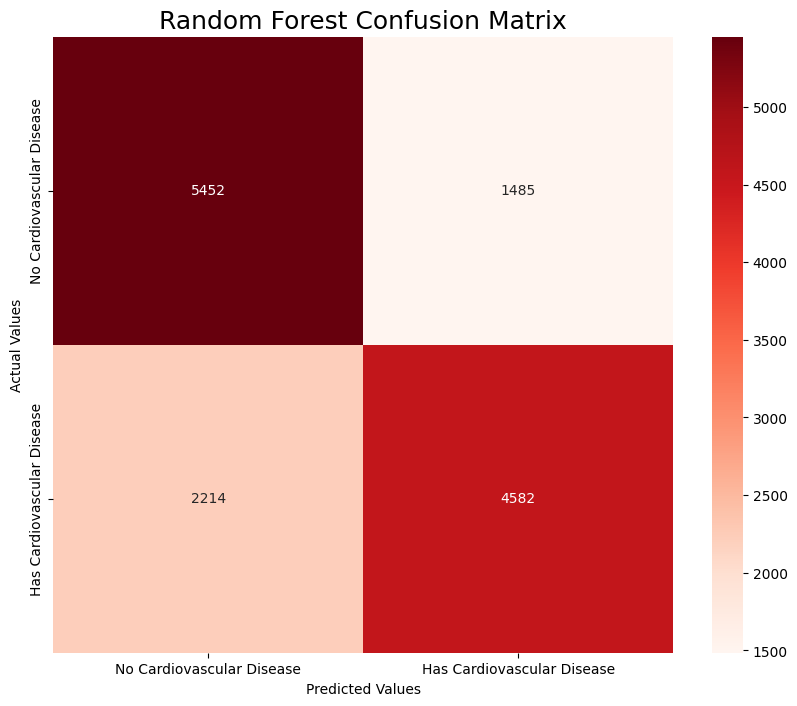



Observe the Confusion Matrix above
It has correctly identified 4582 patients with cardiovascular disease
and 5452 without the disease. These are our true positives and negatives.
On the other hand, the model missed 2214 patients who had the disease
and misdiagnosed 1485 healthy patients. These are our false negatives and positives.


In [28]:
# Random Forest confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_prediction)

plt.figure(figsize=(10,8))

# generate heatmap for confusion matrix
# https://seaborn.pydata.org/generated/seaborn.heatmap.html
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Cardiovascular Disease', 'Has Cardiovascular Disease'],
            yticklabels=['No Cardiovascular Disease', 'Has Cardiovascular Disease'])

plt.title('Random Forest Confusion Matrix', fontsize=18)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

# identify true postivies and false negatives in the matrix
print("\n")
print(f'Observe the Confusion Matrix above')
print(f'It has correctly identified {conf_matrix[1,1]} patients with cardiovascular disease')
print(f'and {conf_matrix[0,0]} without the disease. These are our true positives and negatives.')
print(f'On the other hand, the model missed {conf_matrix[1,0]} patients who had the disease')
print(f'and misdiagnosed {conf_matrix[0,1]} healthy patients. These are our false negatives and positives.' )

## Are we overfitting/underfitting?

Let's compare the training vs test performance of the random forest classifier to see if it is memorizing or generalize

In [29]:
train_accuracy = random_forest.score(X_train, y_train)
test_accuracy = random_forest.score(X_test, y_test)

print(f'Traning accuracy: {train_accuracy}')
print(f'Test accuracy: {test_accuracy}')

accuracy_delta = train_accuracy - test_accuracy

print(f'The difference in accuracy is {accuracy_delta}')
print("Based on that, out model is:")

if accuracy_delta < 0.1:
  print("underfitting!")
elif accuracy_delta < 0.05:
  print("fitting well!")
elif accuracy_delta < 0.10:
  print("sligtly overfitting!")
else:
  print("Overfitting!")

Traning accuracy: 0.742900313114396
Test accuracy: 0.7306488021553921
The difference in accuracy is 0.012251510959003897
Based on that, out model is:
underfitting!


## Could we do better? What about another ML algorithm?

Let's explore a few other models. For model choice, let's consider something that is more complex than Random Forest and something that is less complex. This will give us a better understanding whether random forest is a reasonable model for this dataset.

- [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) - simpler model that can be interpreted through a linear model
- [Gradient Boosting](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) - another ensemble methods that builds trees sequentially

### Losgistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# build and train LogisticRegression
logistic_regression = LogisticRegression(max_iter=1000, random_state=42)
logistic_regression.fit(X_train_scaled, y_train)

y_pred_lr = logistic_regression.predict(X_test_scaled)
y_pred_prob_lr = logistic_regression.predict_proba(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

print("Logistic Regression Classification Summary:")
print(classification_report(y_test, y_pred_lr,
                            target_names=['No Cardio', 'Has Cardio']))

Logistic Regression Accuracy: 0.7202359280565063
Logistic Regression Classification Summary:
              precision    recall  f1-score   support

   No Cardio       0.70      0.78      0.74      6937
  Has Cardio       0.74      0.66      0.70      6796

    accuracy                           0.72     13733
   macro avg       0.72      0.72      0.72     13733
weighted avg       0.72      0.72      0.72     13733



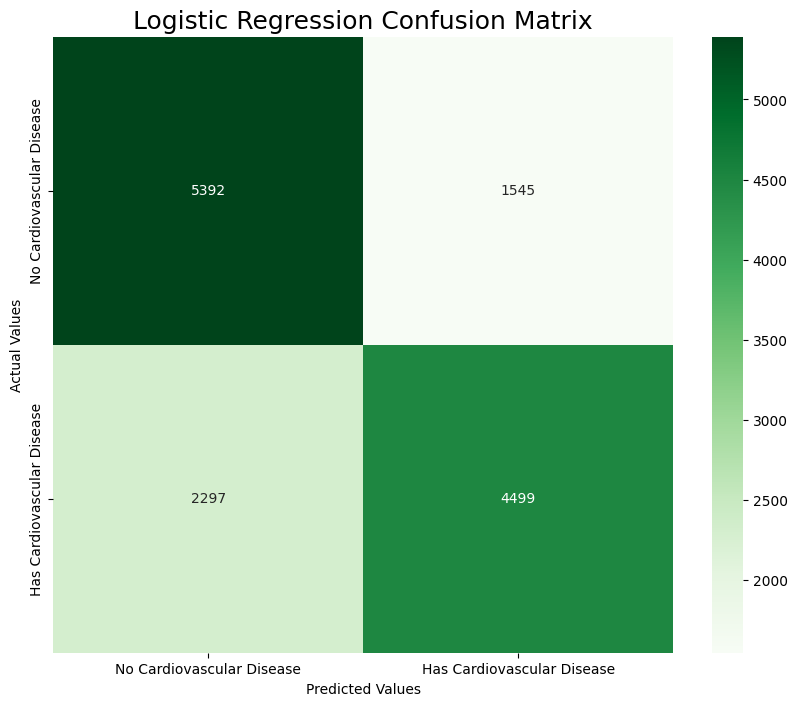

In [31]:
# Logistic Regression Heatmap
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Cardiovascular Disease', 'Has Cardiovascular Disease'],
            yticklabels=['No Cardiovascular Disease', 'Has Cardiovascular Disease'])

plt.title('Logistic Regression Confusion Matrix', fontsize=18)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

### Gradient Boosting

In [32]:
from sklearn.ensemble import GradientBoostingClassifier

# build model
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

gradient_boosting.fit(X_train, y_train)

# predict
y_pred_gb = gradient_boosting.predict(X_test)
y_pred_prod_gb = gradient_boosting.predict_proba(X_test)[:, 1]

# Gradient Boosting metrics
print("Gradient Boosting Summary:")
print(classification_report(y_test, y_pred_gb,
                            target_names=['No Cardio', 'Has Cardio']))


Gradient Boosting Summary:
              precision    recall  f1-score   support

   No Cardio       0.71      0.77      0.74      6937
  Has Cardio       0.75      0.68      0.71      6796

    accuracy                           0.73     13733
   macro avg       0.73      0.73      0.73     13733
weighted avg       0.73      0.73      0.73     13733



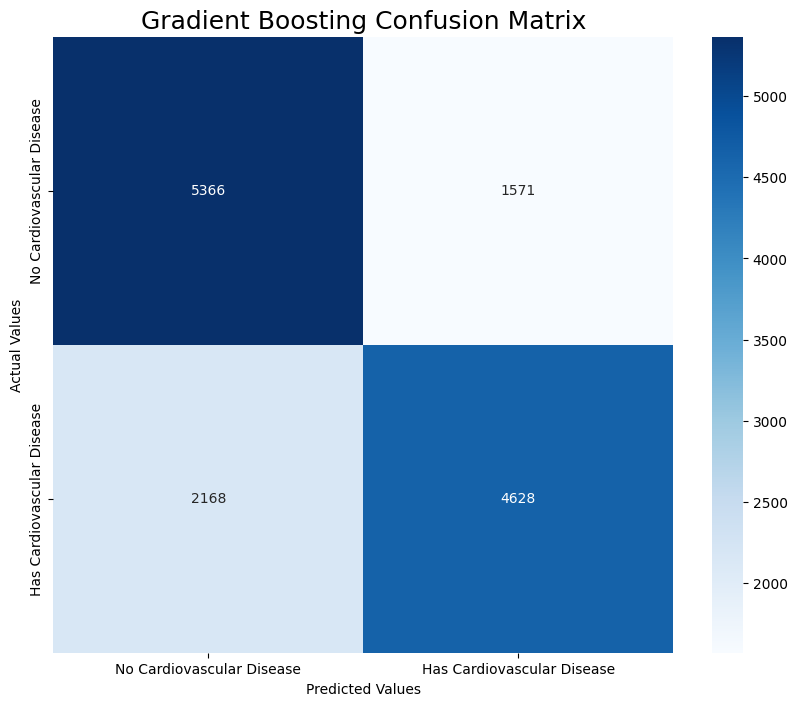

In [33]:
# Gradient Boosting heatmap

conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(10,8))

sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Cardiovascular Disease', 'Has Cardiovascular Disease'],
            yticklabels=['No Cardiovascular Disease', 'Has Cardiovascular Disease'])

plt.title('Gradient Boosting Confusion Matrix', fontsize=18)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

### Let's visualize all three models side by side

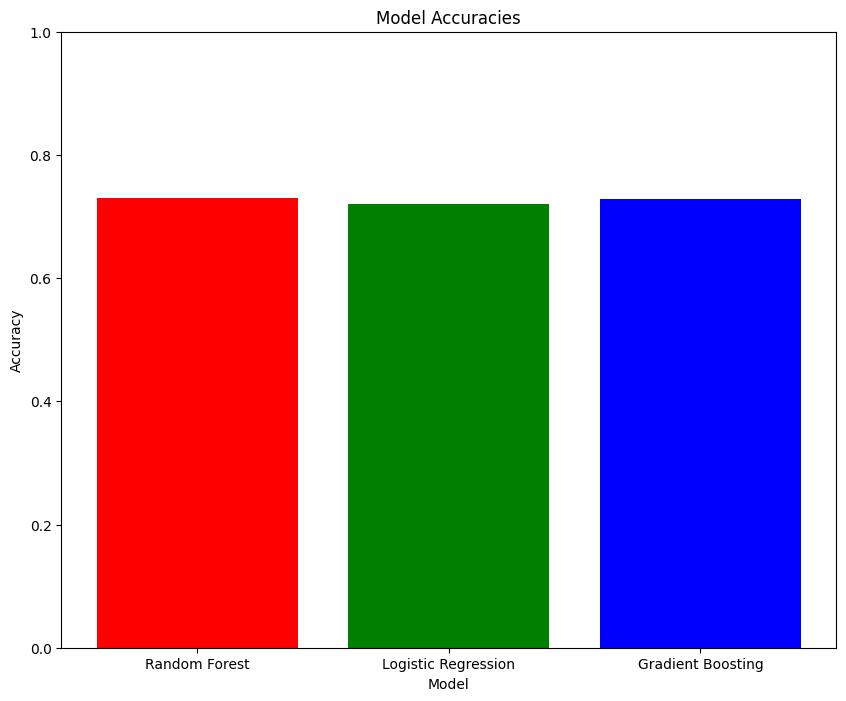

In [34]:
import matplotlib.pyplot as plt

# test accuracies
test_accuracy_rf = accuracy_score(y_test, y_pred_rf)
test_accuracy_lr = accuracy_score(y_test, y_pred_lr)
test_accuracy_gb = accuracy_score(y_test, y_pred_gb)
accuracies = [test_accuracy_rf, test_accuracy_lr, test_accuracy_gb]


plt.figure(figsize=(10, 8))
plt.bar(['Random Forest','Logistic Regression','Gradient Boosting'],
        accuracies,
        color = ['red', 'green', 'blue'])
plt.title('Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()

## Insights